In [1]:
import sys

sys.path.append('..')

import pandas as pd

from linearpost.metrics import MetricLogger
import result_helpers

## arXiv:2405.04025v3

"A Unified Post-Processing Framework for Group Fairness in Classification"

The results in the paper can be reproduced by running the following commands.

Note that decision calibration is not performed when post-processing for SP under the attribute-aware setting, because the group membership predictor is already calibrated since the sensitive attribute $A$ is observed.

```bash
# Adult

python step1_train_predict_tabular.py --seed 33 --dataset_getter_name xz24_adult_blind --model logreg lgbm
python step2_linearpost.py --seed 33 --cache_fname xz24_adult_blind_logreg xz24_adult_blind_lgbm
python step2_linearpost.py --seed 33 --cache_fname xz24_adult_blind_logreg xz24_adult_blind_lgbm --dcal --split_ratio_dcal 0.5

python step1_train_predict_tabular.py --seed 33 --dataset_getter_name xz24_adult_aware --attr_aware --model logreg lgbm
python step2_linearpost.py --seed 33 --cache_fname xz24_adult_aware_logreg xz24_adult_aware_lgbm
python step2_linearpost.py --seed 33 --cache_fname xz24_adult_aware_logreg xz24_adult_aware_lgbm --dcal --split_ratio_dcal 0.5 --criteria tpr eo

# COMPAS

python step1_train_predict_tabular.py --seed 33 --dataset_getter_name xz24_compas_blind --model logreg lgbm
python step2_linearpost.py --seed 33 --cache_fname xz24_compas_blind_logreg xz24_compas_blind_lgbm
python step2_linearpost.py --seed 33 --cache_fname xz24_compas_blind_logreg xz24_compas_blind_lgbm --dcal --split_ratio_dcal 0.7

python step1_train_predict_tabular.py --seed 33 --dataset_getter_name xz24_compas_aware --attr_aware --model logreg lgbm
python step2_linearpost.py --seed 33 --cache_fname xz24_compas_aware_logreg xz24_compas_aware_lgbm
python step2_linearpost.py --seed 33 --cache_fname xz24_compas_aware_logreg xz24_compas_aware_lgbm --dcal --split_ratio_dcal 0.7 --criteria tpr eo

# ACSIncome2

python step1_train_predict_tabular.py --seed 33 --dataset_getter_name xz24_acsincome2_blind --model logreg lgbm mlp
python step2_linearpost.py --seed 33 --bootstrap_n_resamples 100 --cache_fname xz24_acsincome2_blind_logreg xz24_acsincome2_blind_lgbm xz24_acsincome2_blind_mlp
python step2_linearpost.py --seed 33 --bootstrap_n_resamples 100 --cache_fname xz24_acsincome2_blind_logreg xz24_acsincome2_blind_lgbm xz24_acsincome2_blind_mlp --dcal --split_ratio_dcal 0.3

python step1_train_predict_tabular.py --seed 33 --dataset_getter_name xz24_acsincome2_aware --attr_aware --model logreg lgbm mlp
python step2_linearpost.py --seed 33 --bootstrap_n_resamples 100 --cache_fname xz24_acsincome2_aware_logreg xz24_acsincome2_aware_lgbm xz24_acsincome2_aware_mlp
python step2_linearpost.py --seed 33 --bootstrap_n_resamples 100 --cache_fname xz24_acsincome2_aware_logreg xz24_acsincome2_aware_lgbm xz24_acsincome2_aware_mlp --dcal --split_ratio_dcal 0.3 --criteria tpr eo

# ACSIncome5

python step1_train_predict_tabular.py --seed 33 --dataset_getter_name xz24_acsincome5_blind --model logreg lgbm mlp
python step2_linearpost.py --seed 33 --bootstrap_n_resamples 100 --cache_fname xz24_acsincome5_blind_logreg xz24_acsincome5_blind_lgbm xz24_acsincome5_blind_mlp
python step2_linearpost.py --seed 33 --bootstrap_n_resamples 100 --cache_fname xz24_acsincome5_blind_logreg xz24_acsincome5_blind_lgbm xz24_acsincome5_blind_mlp --dcal --split_ratio_dcal 0.5

python step1_train_predict_tabular.py --seed 33 --dataset_getter_name xz24_acsincome5_aware --attr_aware --model logreg lgbm mlp
python step2_linearpost.py --seed 33 --bootstrap_n_resamples 100 --cache_fname xz24_acsincome5_aware_logreg xz24_acsincome5_aware_lgbm xz24_acsincome5_aware_mlp
python step2_linearpost.py --seed 33 --bootstrap_n_resamples 100 --cache_fname xz24_acsincome5_aware_logreg xz24_acsincome5_aware_lgbm xz24_acsincome5_aware_mlp --dcal --split_ratio_dcal 0.5 --criteria tpr eo

# BiasBios

python train_predict_textual.py --seed 33 --dataset_getter_name xz24_biasbios --model google-bert/bert-base-uncased
python step2_linearpost.py --seed 33 --bootstrap_n_resamples 100 --cache_fname xz24_biasbios_bert-base-uncased
python step2_linearpost.py --seed 33 --bootstrap_n_resamples 100 --cache_fname xz24_biasbios_bert-base-uncased --dcal --split_ratio_dcal 0.4
```

In [2]:
# Experiment tracker

result_paths = result_helpers.get_xz24_result_paths()

result_counts = []
for dataset_name in result_paths:
  for model in result_paths[dataset_name]:
    for aware in result_paths[dataset_name][model]:
      for method in result_paths[dataset_name][model][aware]:
        result_count = {
            'dataset': dataset_name + (' (aware)' if aware else ' (blind)'),
            'model': model,
            'method': method
        }
        for criterion in result_paths[dataset_name][model][aware][method]:
          result_path = result_paths[dataset_name][model][aware][method][
              criterion]
          result_count[criterion] = len(
              MetricLogger.from_path(result_path.format(split='test')))
        if len(result_count) > 3:
          # has result for at least one criterion
          result_counts.append(result_count)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
  df = pd.DataFrame(result_counts)
  df = df.set_index(['dataset', 'model', 'method'])
  df = df.astype(
      {c: 'Int64' for c in result_helpers.xz24_criteria if c in df.columns})
  s = df.style.map(
      lambda v: 'background-color: rgba(228, 208, 10, 0.3);' if v > 0 else None,
      subset=[c for c in result_helpers.xz24_criteria if c in df.columns],
  ).map(
      lambda v: 'background-color: rgba(34, 139, 34, 0.3);'
      if v == result_helpers.xz24_n_alphas else None,
      subset=[c for c in result_helpers.xz24_criteria if c in df.columns],
  )
  display(s)

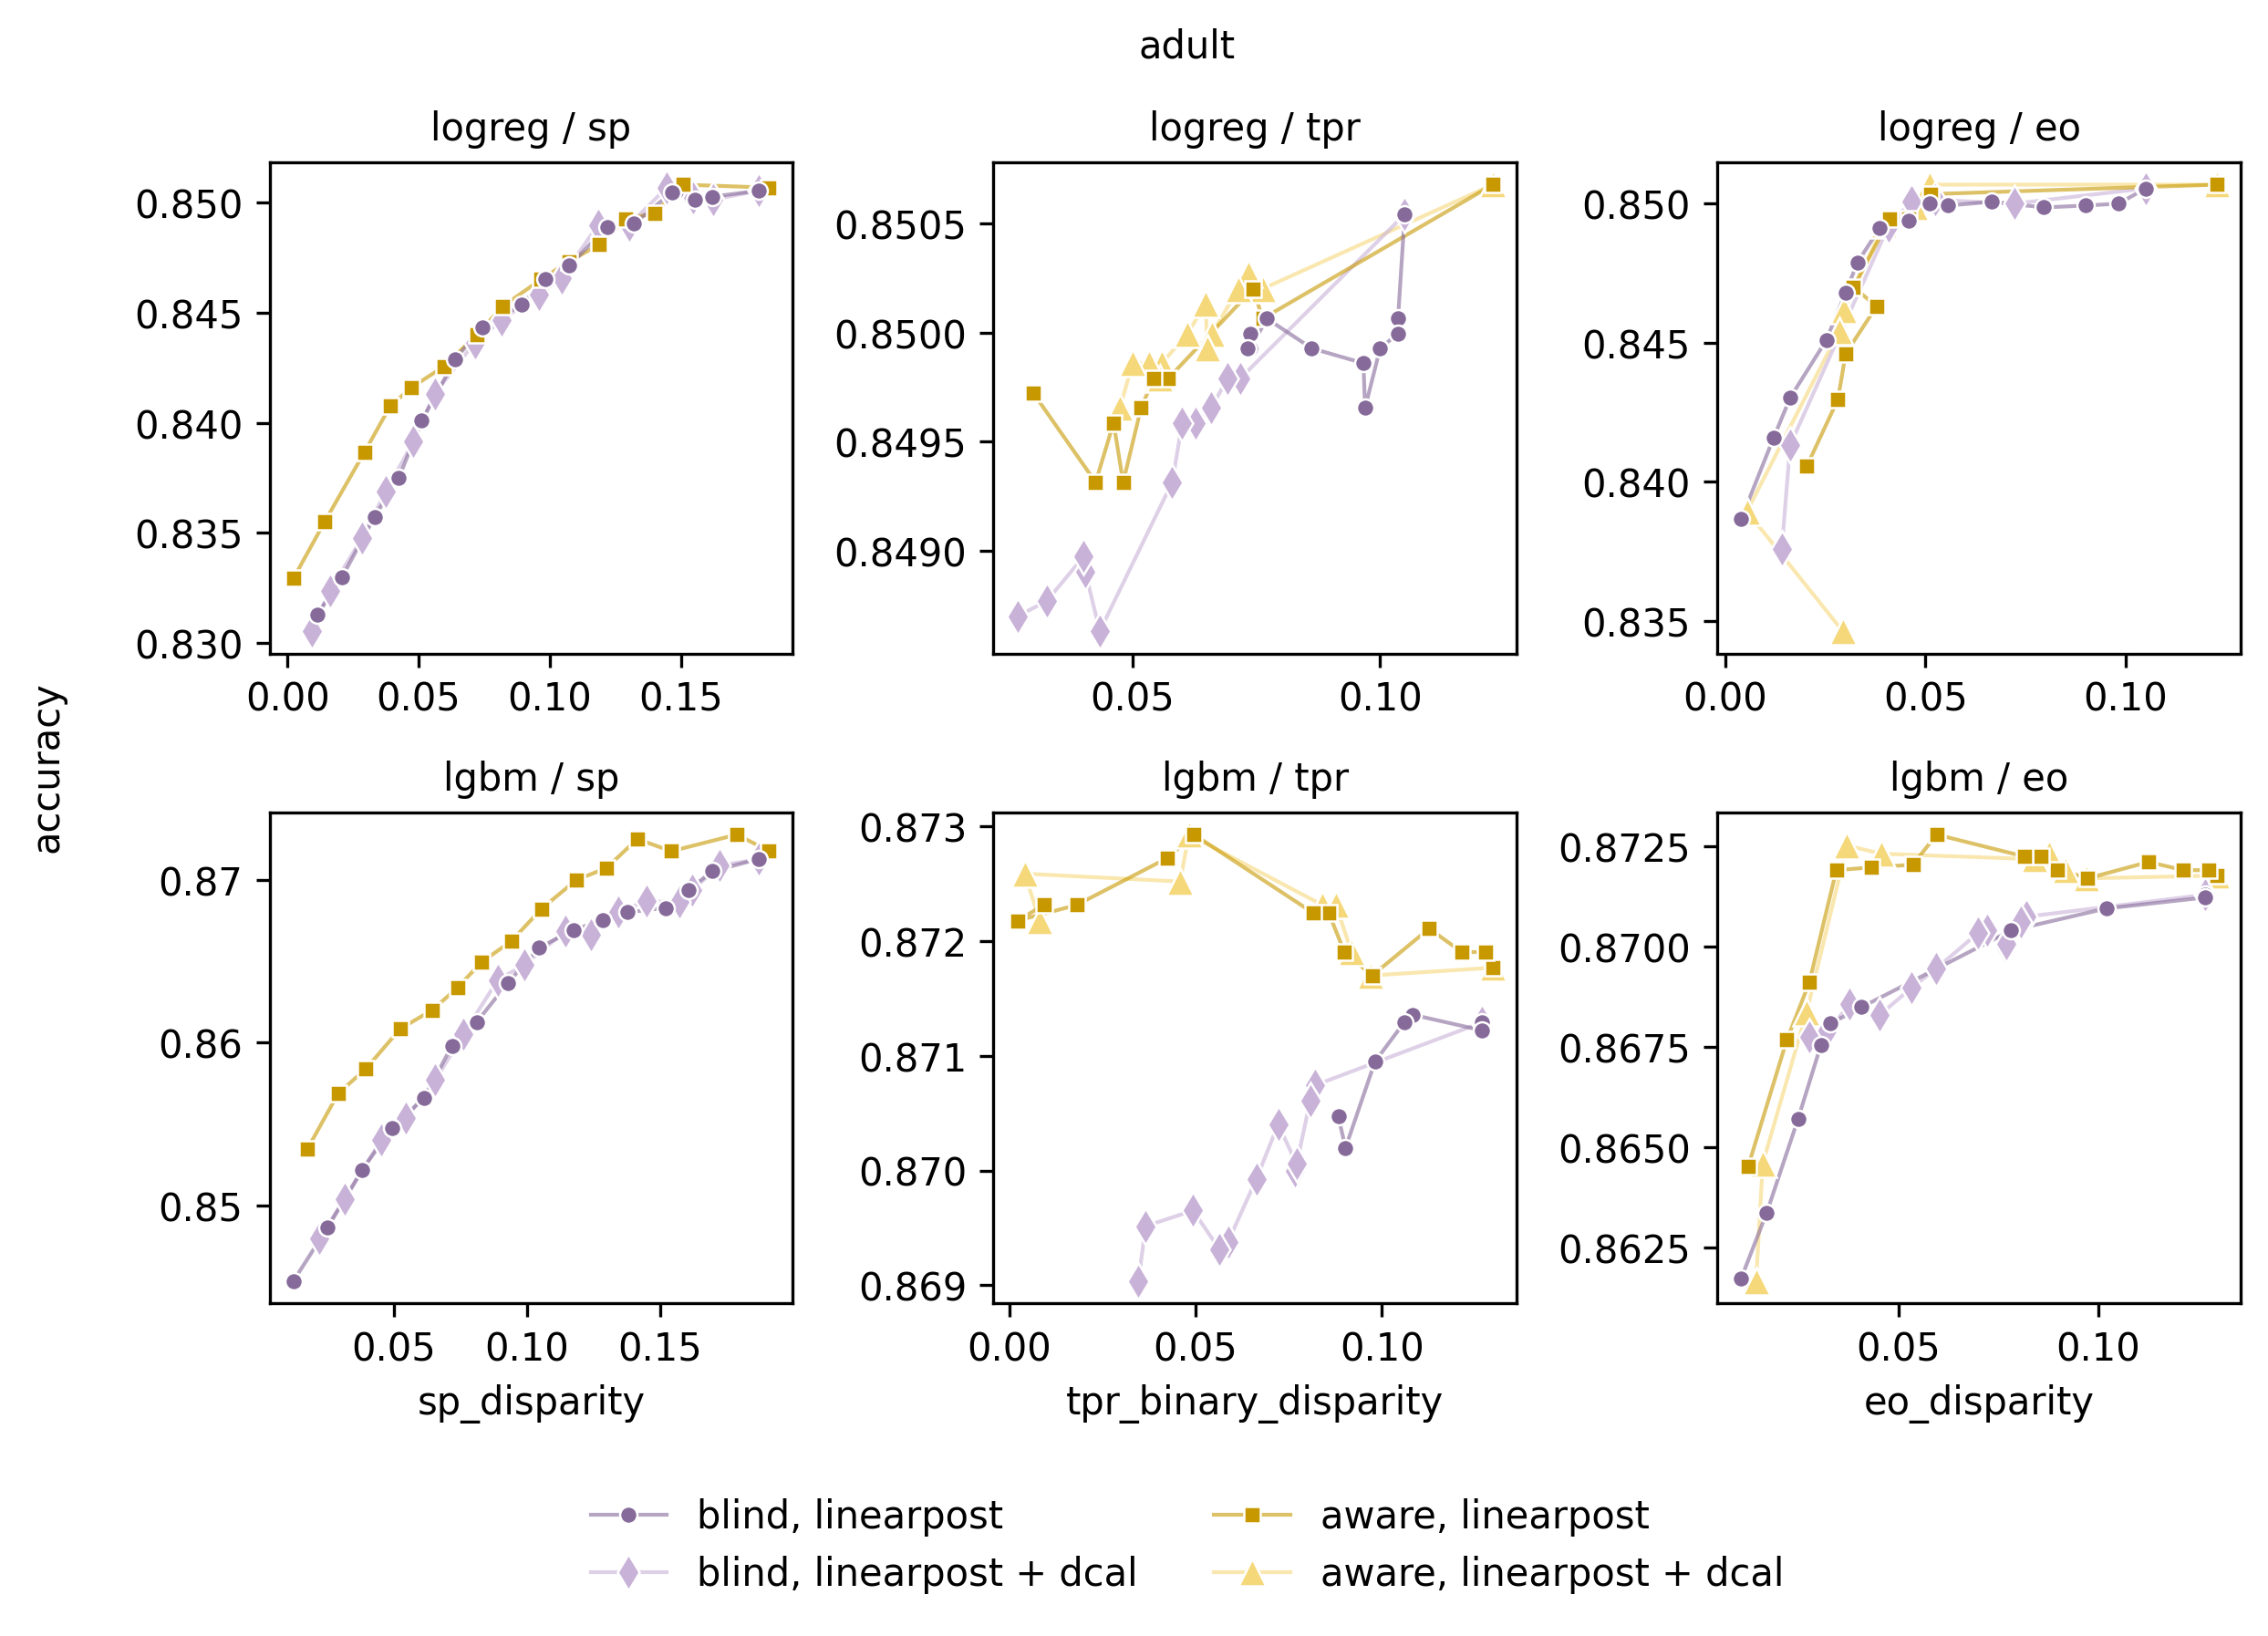

In [3]:
fig, axs = result_helpers.plot_xz24_dataset('adult',
                                            weighted_fairness_criterion=False)

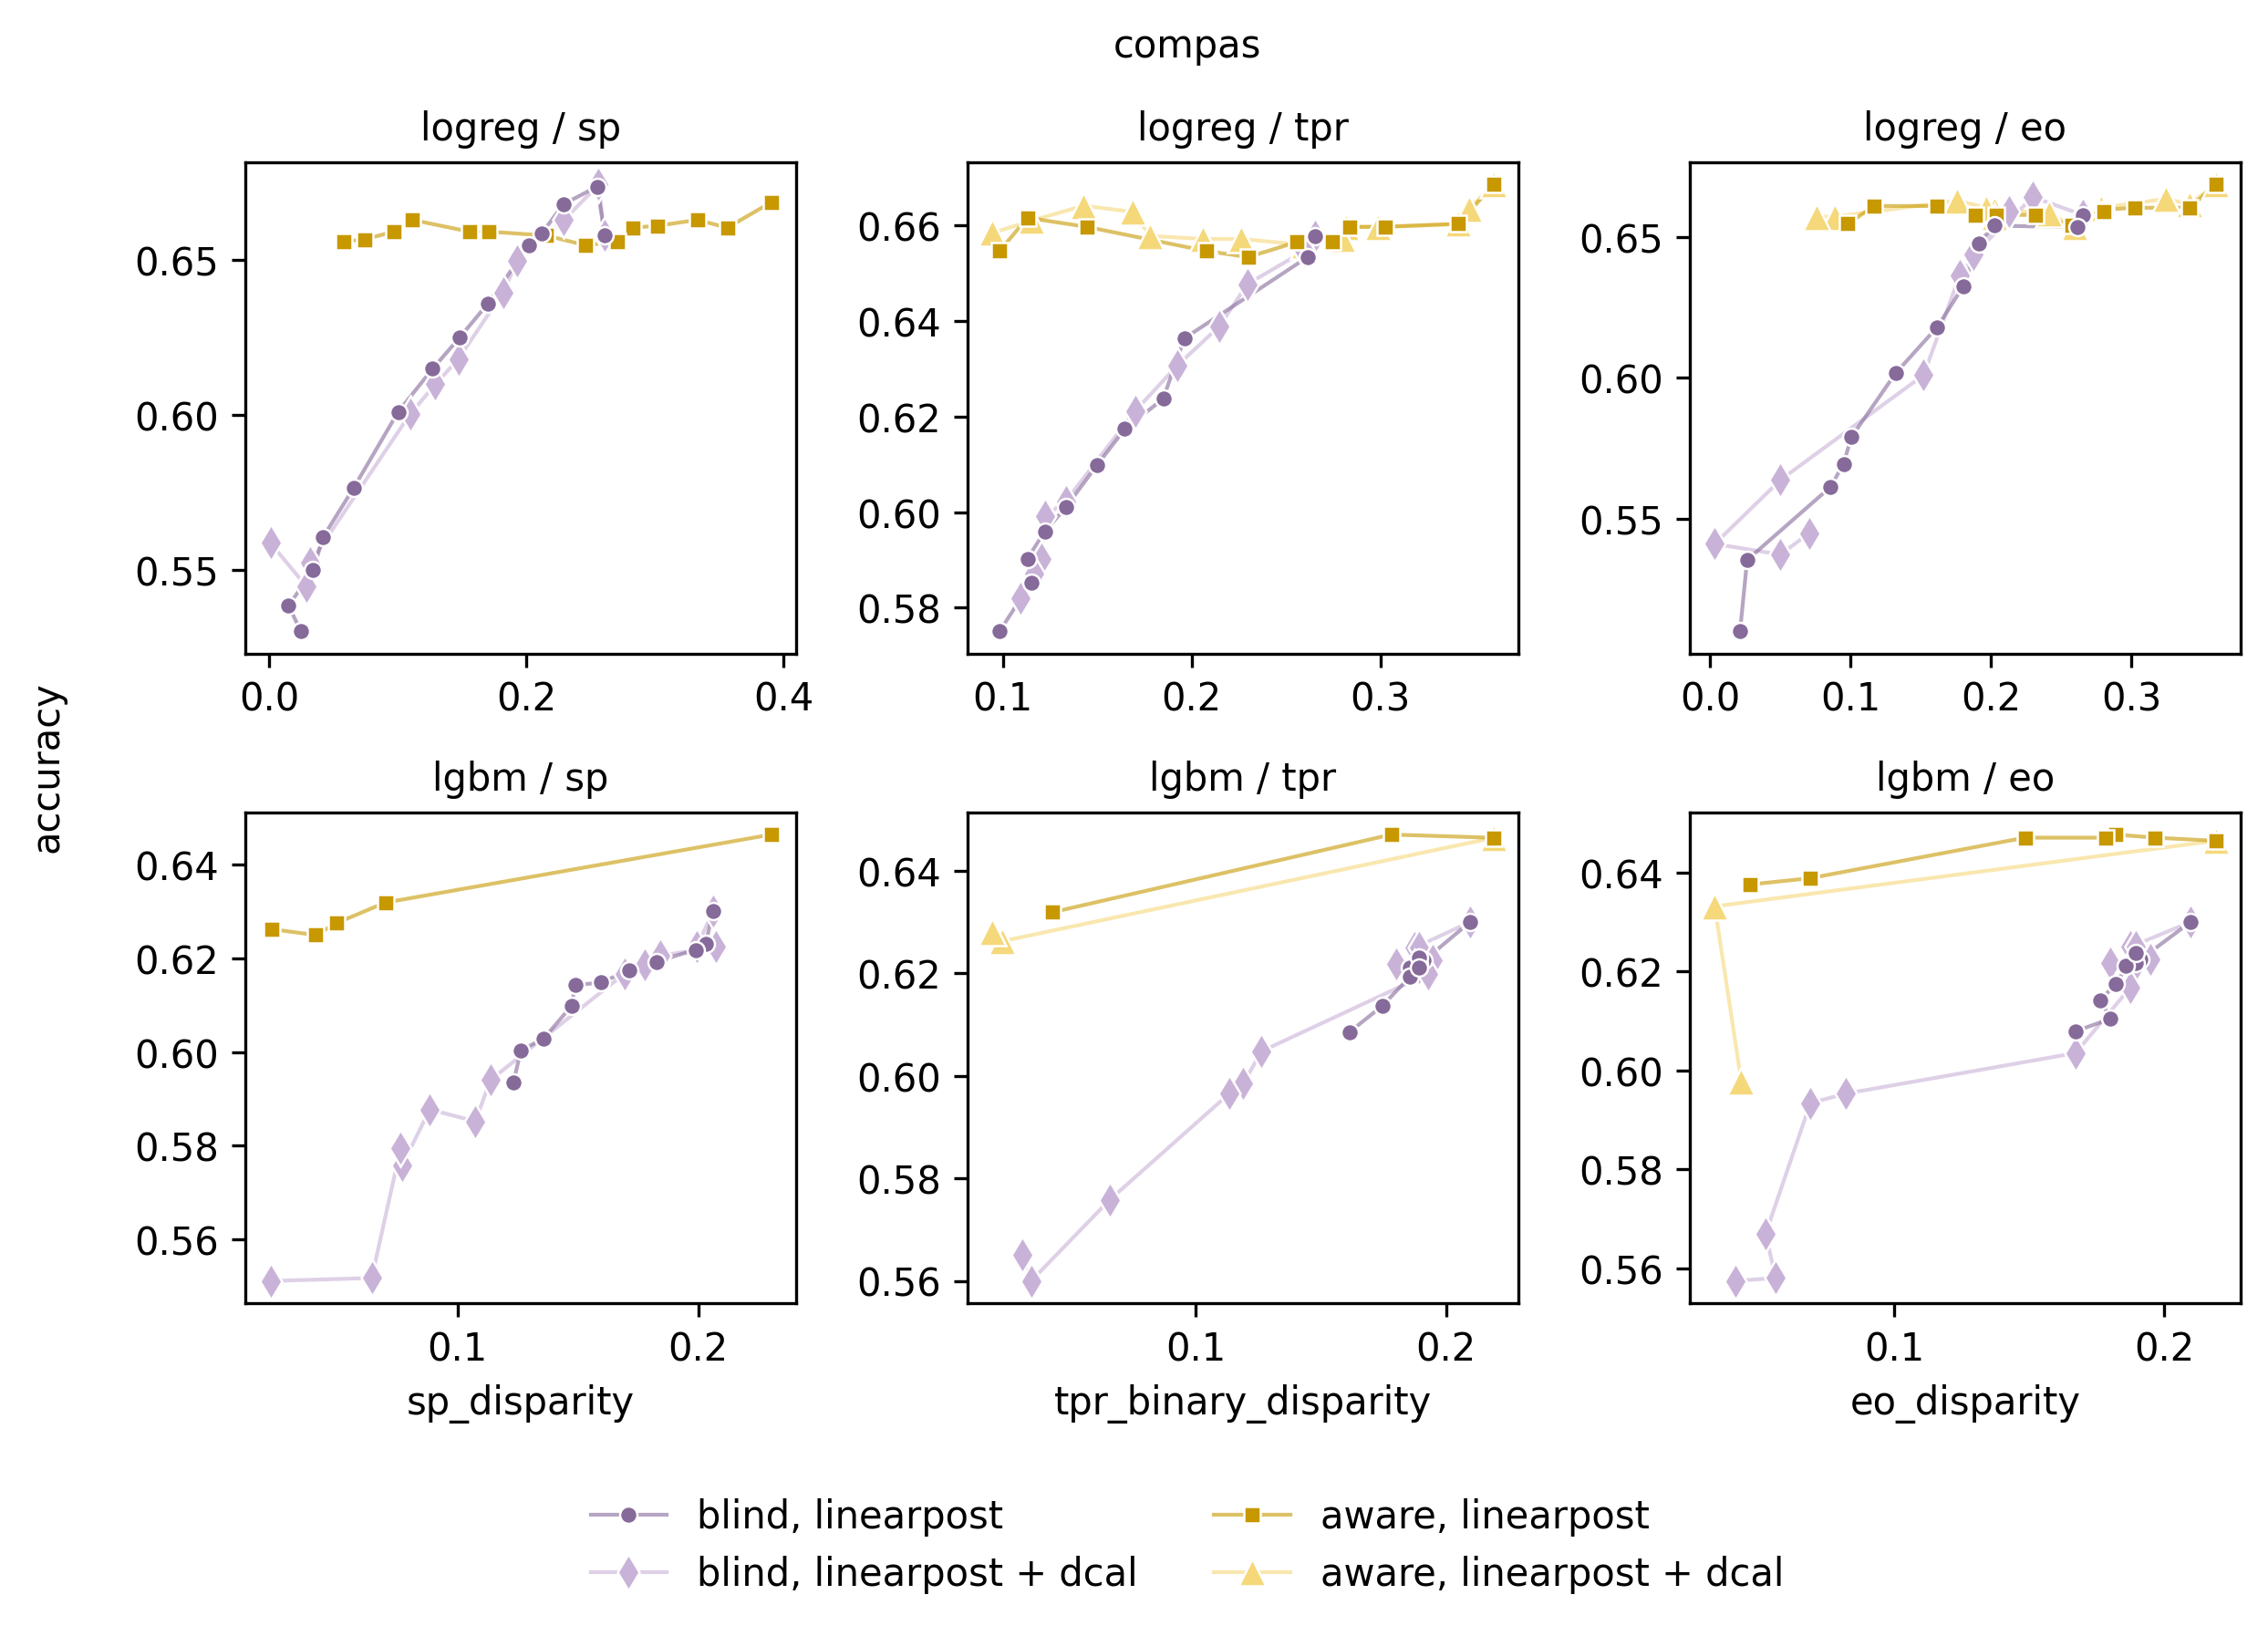

In [4]:
fig, axs = result_helpers.plot_xz24_dataset('compas',
                                            weighted_fairness_criterion=False)

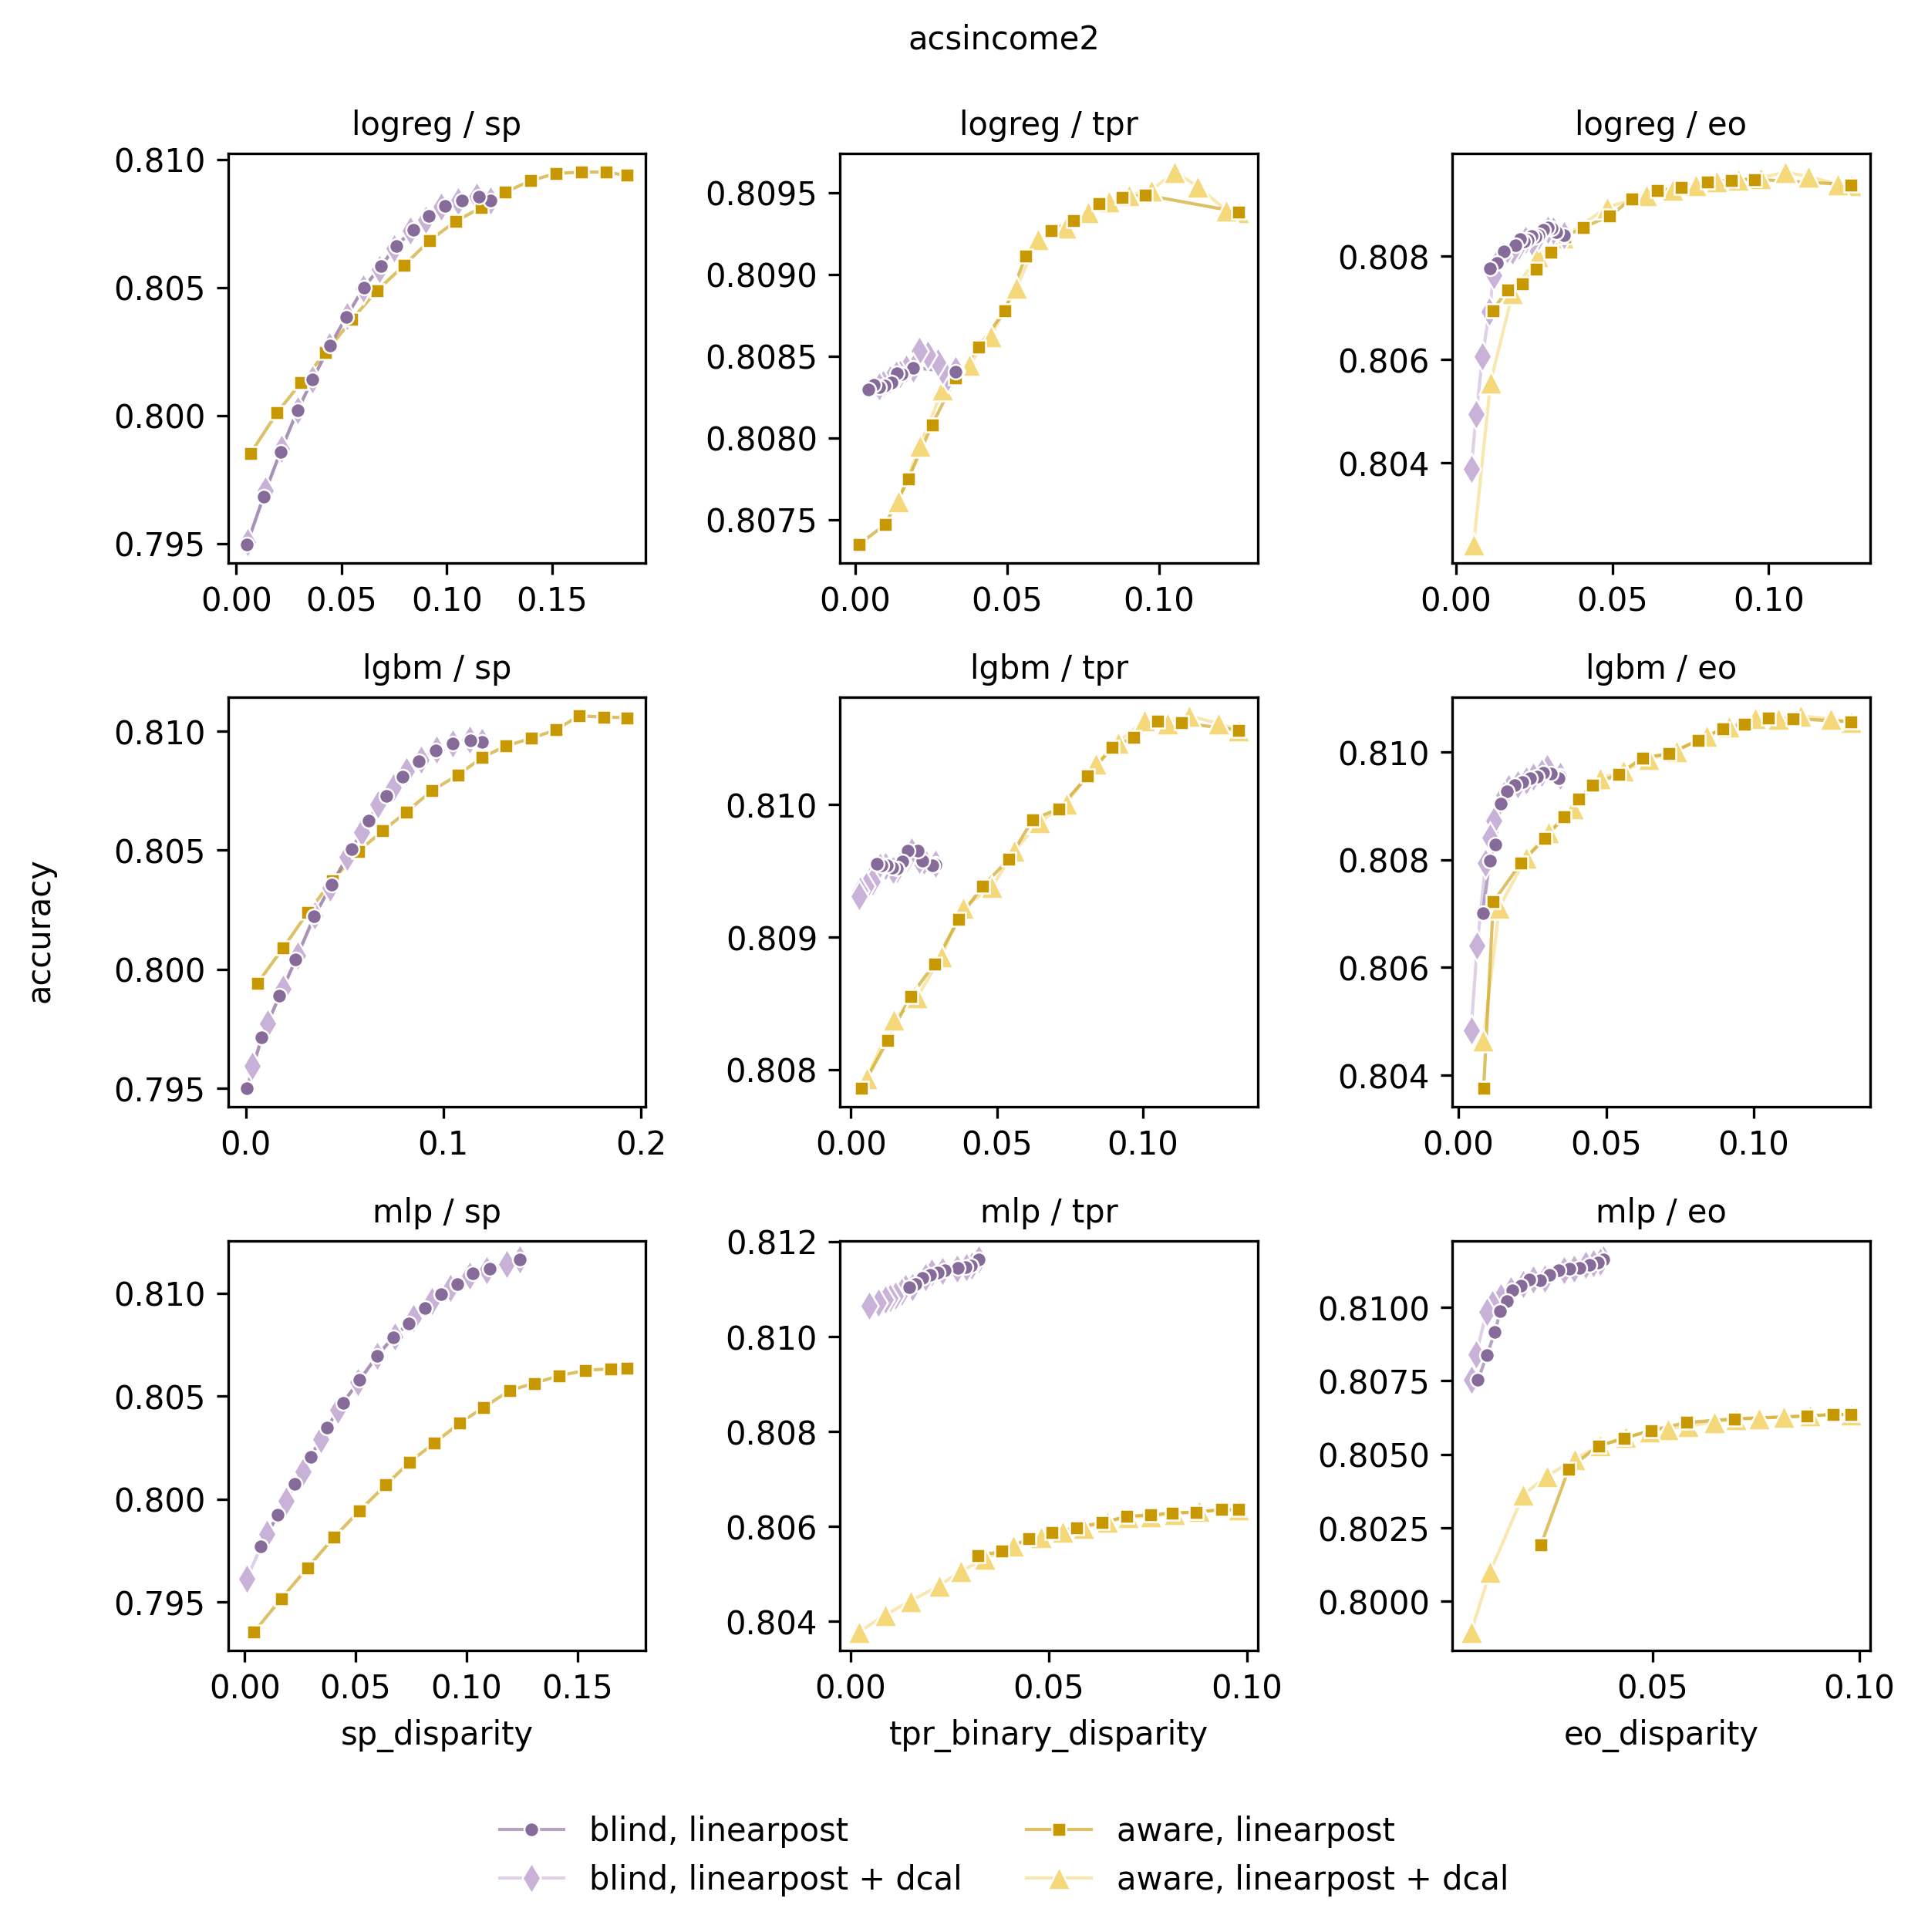

In [5]:
fig, axs = result_helpers.plot_xz24_dataset('acsincome2',
                                            weighted_fairness_criterion=False)

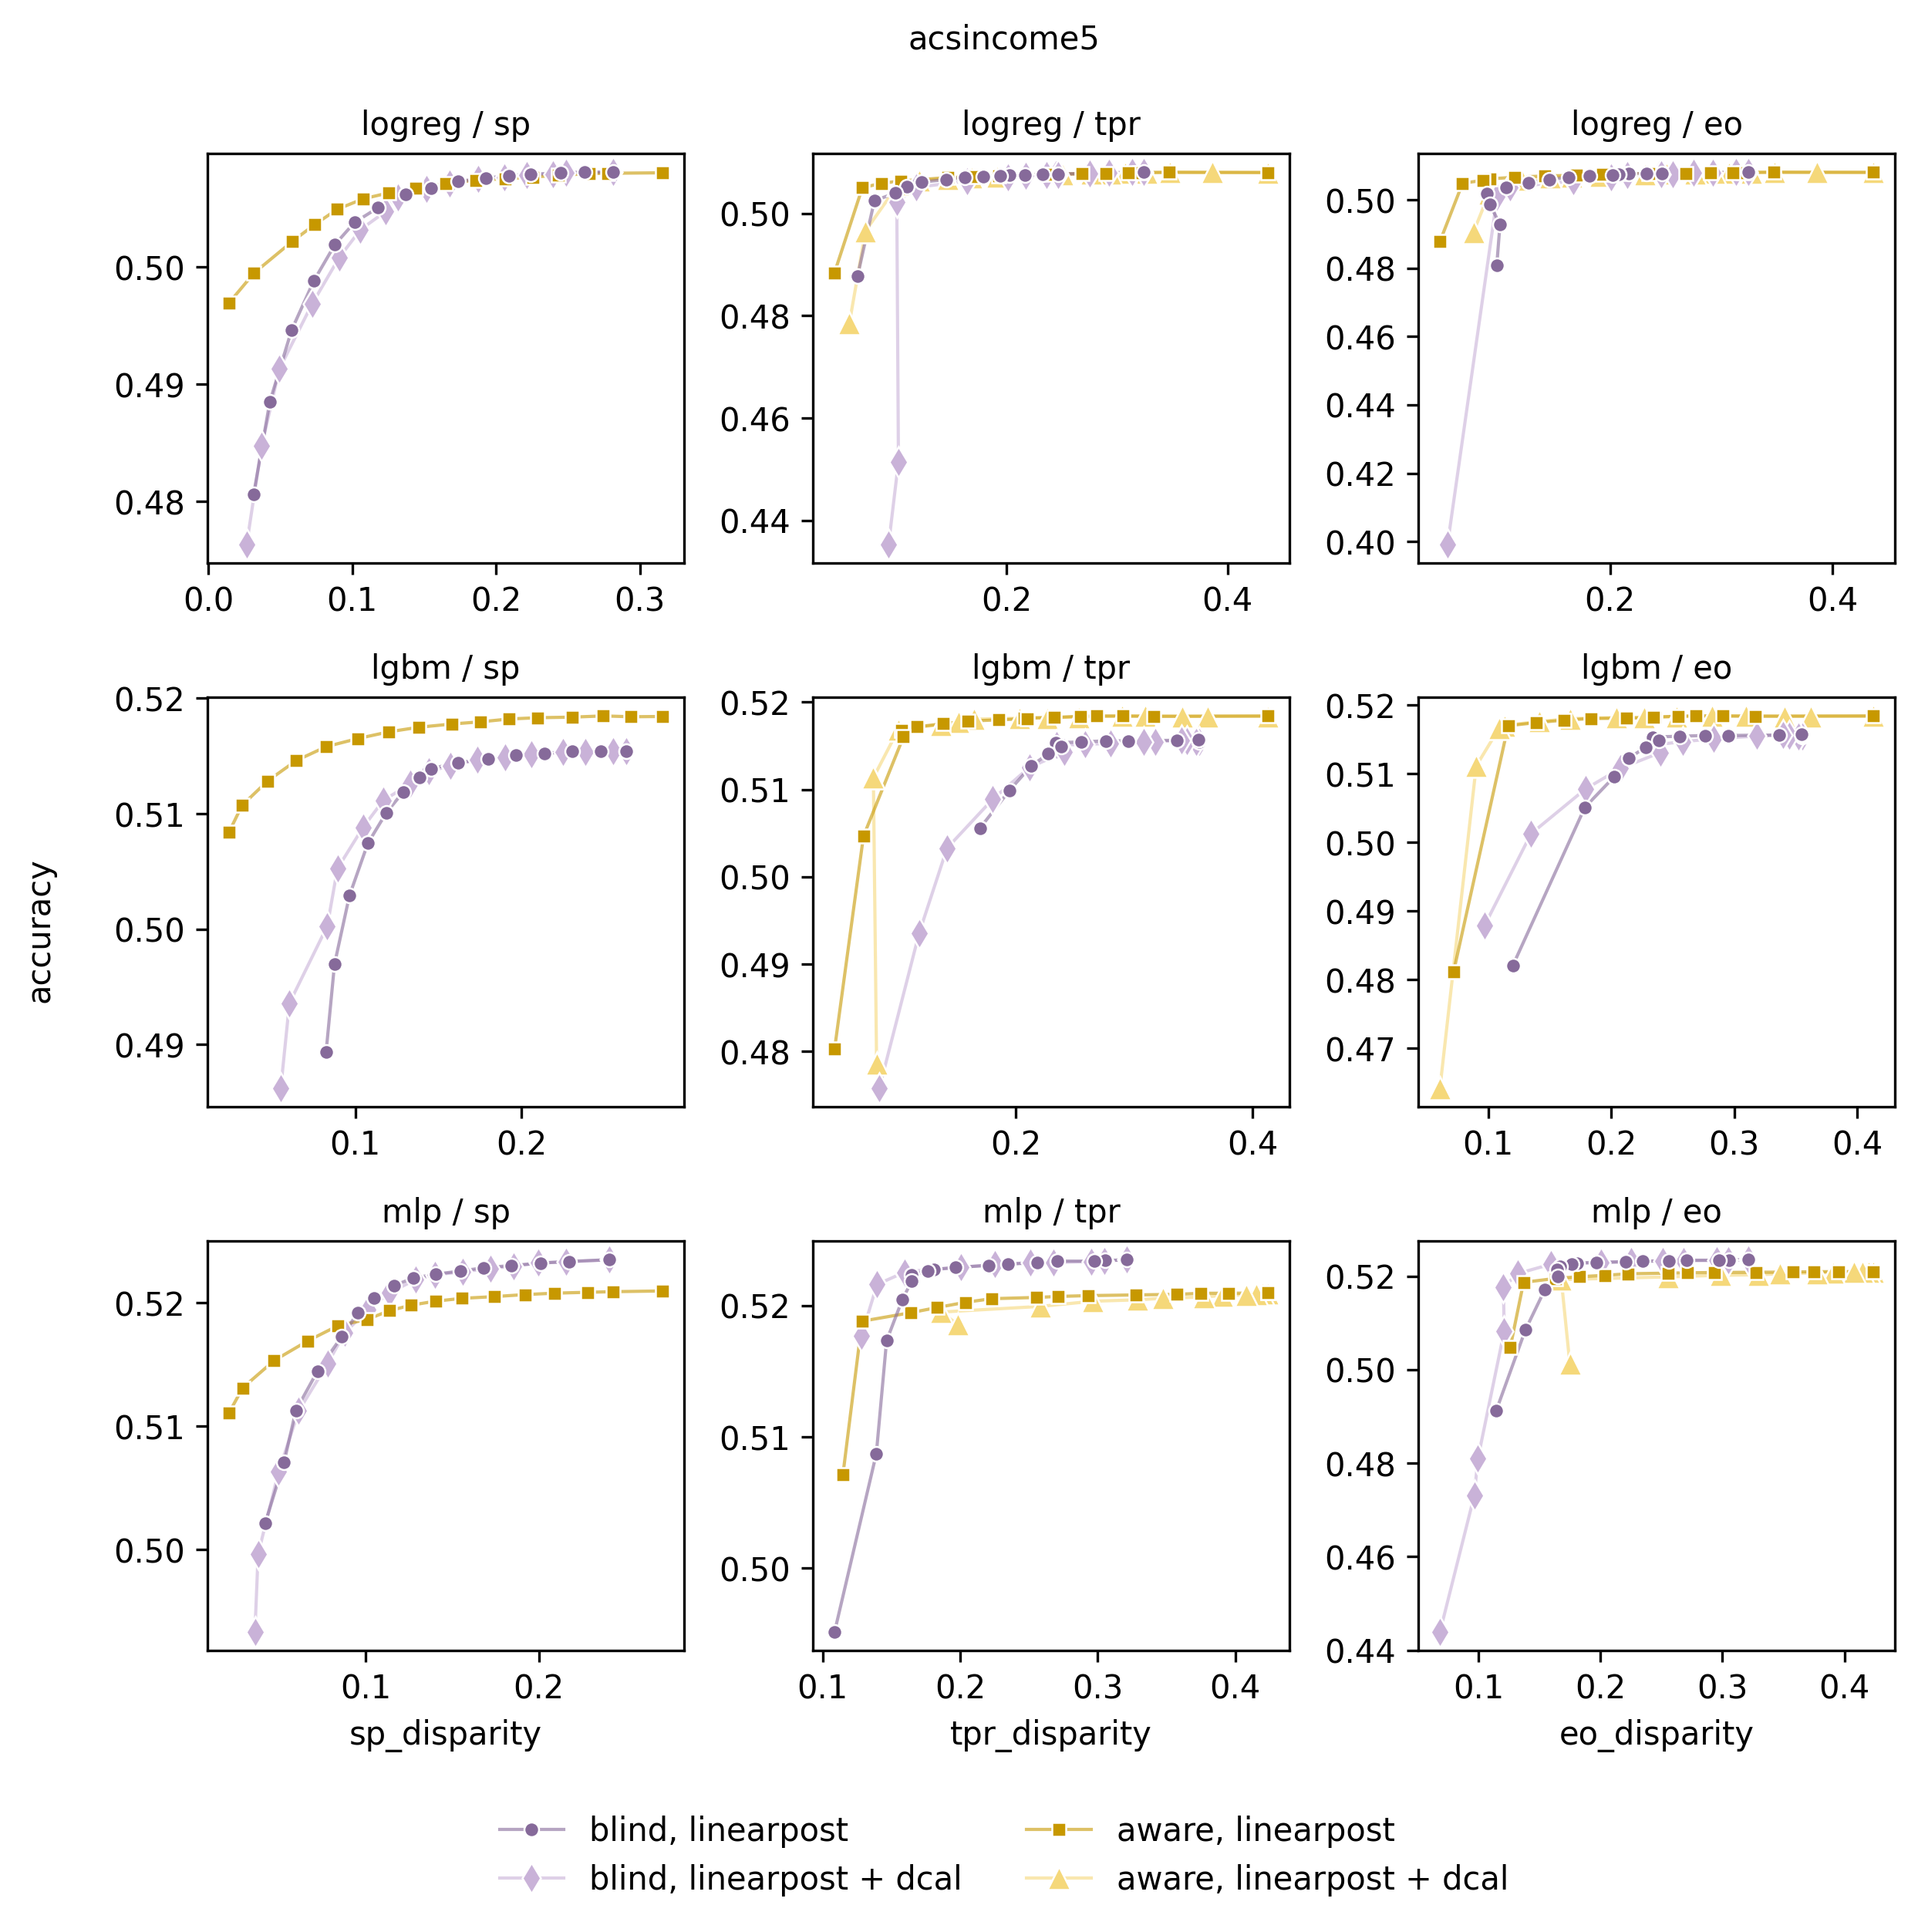

In [6]:
fig, axs = result_helpers.plot_xz24_dataset('acsincome5',
                                            weighted_fairness_criterion=False)

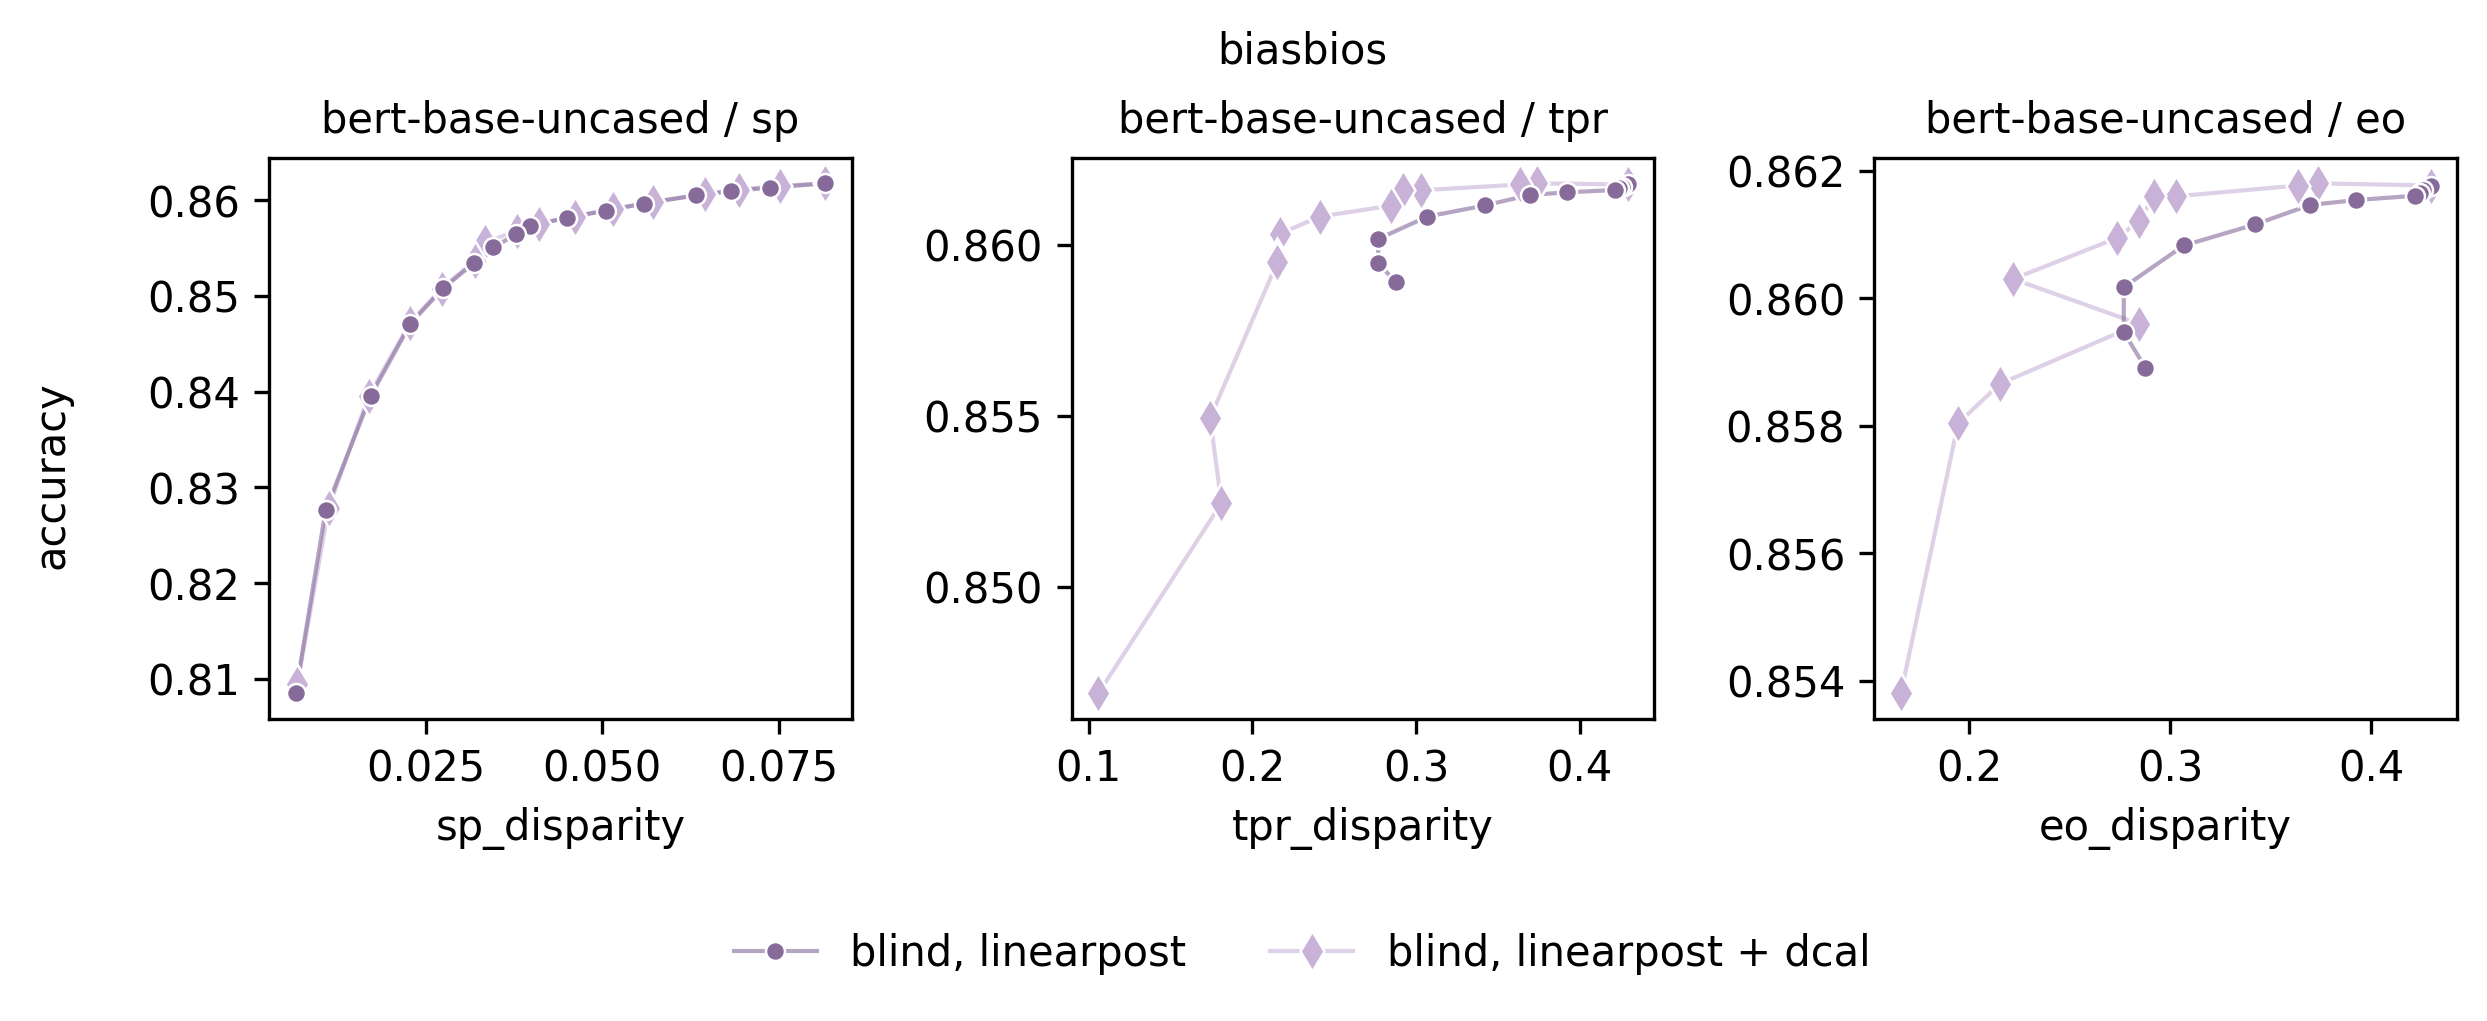

In [7]:
fig, axs = result_helpers.plot_xz24_dataset('biasbios',
                                            weighted_fairness_criterion=False)